# Variant 2 spatial distributions

Item spawn counts and pickup locations for Greedy and DQN v8.5.31, evaluated on the same 100 Variant 2 validation episodes.

In [10]:
from collections import deque
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display
import numpy as np
import pandas as pd
import torch

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'statistic' else NOTEBOOK_DIR
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import rainbow_dqn
from environment_v5 import Environment_v5

DATA_DIR = PROJECT_ROOT / 'data'
MODEL_ROOT = PROJECT_ROOT / 'models2'
VARIANT = 2
NUM_VALIDATION_EPISODES = 100

MODEL_RUNS = [
    {
        'name': 'v8.5.31',
        'env_class': Environment_v5,
        'model_path': MODEL_ROOT / 'DQN_v8.5.31_variant_2.pt',
    },
]

episode_ids = pd.read_csv(
    DATA_DIR / 'variant_2' / 'validation_episodes.csv'
)['validation_episodes'].head(NUM_VALIDATION_EPISODES).astype(int).tolist()

print(f'Project root: {PROJECT_ROOT}')
print(f'Validation episodes: {len(episode_ids)}')

Project root: /Users/zlr/Documents/CodingLab：DRL/CodingLab_DRL_team
Validation episodes: 100


In [11]:
def blocked_cells_for(env):
    eligible = set(env.eligible_cells)
    return [
        (row, col)
        for row in range(env.vertical_cell_count)
        for col in range(env.horizontal_cell_count)
        if (row, col) not in eligible
    ]


def shortest_path(env, start, goal):
    if start == goal:
        return [start]

    eligible = set(env.eligible_cells)
    queue = deque([start])
    predecessor = {start: None}
    while queue:
        row, col = queue.popleft()
        for neighbor in ((row - 1, col), (row, col + 1), (row + 1, col), (row, col - 1)):
            if neighbor not in eligible or neighbor in predecessor:
                continue
            predecessor[neighbor] = (row, col)
            if neighbor == goal:
                path = [goal]
                while path[-1] != start:
                    path.append(predecessor[path[-1]])
                return list(reversed(path))
            queue.append(neighbor)
    raise ValueError(f'No path from {start} to {goal}')


def graph_distance(env, start, goal):
    return len(shortest_path(env, start, goal)) - 1


def action_towards(env, goal):
    path = shortest_path(env, env.agent_loc, goal)
    if len(path) == 1:
        return 0
    next_row, next_col = path[1]
    row, col = env.agent_loc
    delta = (next_row - row, next_col - col)
    return {(-1, 0): 1, (0, 1): 2, (1, 0): 3, (0, -1): 4}[delta]


def greedy_action(env):
    if env.agent_load == env.agent_capacity:
        return action_towards(env, env.target_loc)

    candidates = []
    for item_loc, item_time in zip(env.item_locs, env.item_times):
        agent_item_distance = graph_distance(env, env.agent_loc, item_loc)
        if agent_item_distance > env.max_response_time - item_time:
            continue
        total_distance = agent_item_distance + graph_distance(env, item_loc, env.target_loc)
        profit = env.reward - total_distance
        if profit > 0:
            candidates.append((profit, item_loc))

    if not candidates:
        return 0
    _, best_item = max(candidates, key=lambda candidate: candidate[0])
    return action_towards(env, best_item)


def load_policy(env, model_path):
    policy = rainbow_dqn.DQN_v8(env)
    policy.device = torch.device('cpu')
    policy.support = policy.support.to(policy.device)
    policy.q_network.to(policy.device)
    policy.target_network.to(policy.device)
    policy.q_network.load_state_dict(torch.load(model_path, map_location=policy.device))
    policy.q_network.eval()
    policy.epsilon = 0
    return policy


def rollout_pickup_counts(env, action_selector, validation_episode_ids):
    counts = np.zeros((env.vertical_cell_count, env.horizontal_cell_count), dtype=np.int64)
    for episode_id in validation_episode_ids:
        env.validation_episodes = [int(episode_id)]
        env.validation_episode_counter = 0
        obs = env.reset('validation')
        for _ in range(env.episode_steps):
            action = int(action_selector(env, obs))
            items_before_step = set(env.item_locs)
            had_free_capacity = env.agent_load < env.agent_capacity
            _, obs, done = env.step(action)
            if had_free_capacity and env.agent_loc in items_before_step:
                counts[env.agent_loc] += 1
            if done:
                break
    return counts


reference_env = Environment_v5(variant=VARIANT, data_dir=str(DATA_DIR))
blocked_cells = blocked_cells_for(reference_env)
pickup_counts = {}

print('Rolling out Greedy...')
greedy_env = Environment_v5(variant=VARIANT, data_dir=str(DATA_DIR))
pickup_counts['Greedy'] = rollout_pickup_counts(
    greedy_env, lambda env, obs: greedy_action(env), episode_ids
)

for run in MODEL_RUNS:
    print(f"Rolling out {run['name']}...")
    env = run['env_class'](variant=VARIANT, data_dir=str(DATA_DIR))
    policy = load_policy(env, run['model_path'])
    pickup_counts[run['name']] = rollout_pickup_counts(
        env, lambda env, obs, policy=policy: policy.select_action(obs), episode_ids
    )

item_spawn_counts = np.zeros((5, 5), dtype=np.int64)
for episode_id in episode_ids:
    episode_data = pd.read_csv(
        DATA_DIR / 'variant_2' / 'episode_data' / f'episode_{episode_id:03d}.csv',
        index_col=0,
    )
    for row, col in zip(episode_data['vertical_idx'], episode_data['horizontal_idx']):
        item_spawn_counts[int(row), int(col)] += 1

summary = pd.DataFrame({
    'policy': list(pickup_counts),
    'total_pickups': [grid.sum() for grid in pickup_counts.values()],
    'pickup_cells': [
        sum(grid[row, col] > 0 for row, col in reference_env.eligible_cells)
        for grid in pickup_counts.values()
    ],
})
display(summary)
print(f'Total item spawns: {item_spawn_counts.sum():,}')

Rolling out Greedy...
Rolling out v8.5.31...
Using device: cpu


,policy,total_pickups,pickup_cells
0,Greedy,1670,17
1,v8.5.31,1350,11


Total item spawns: 3,376


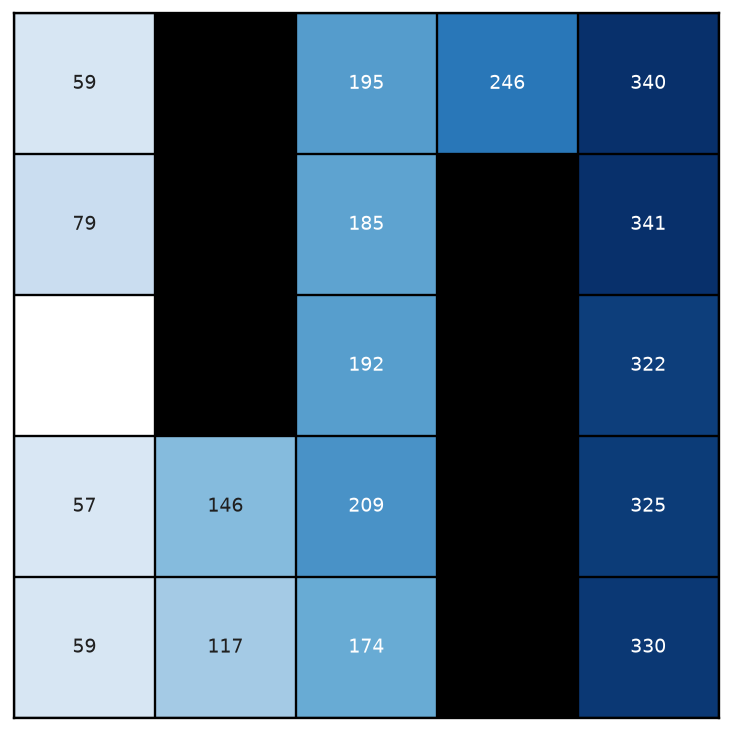

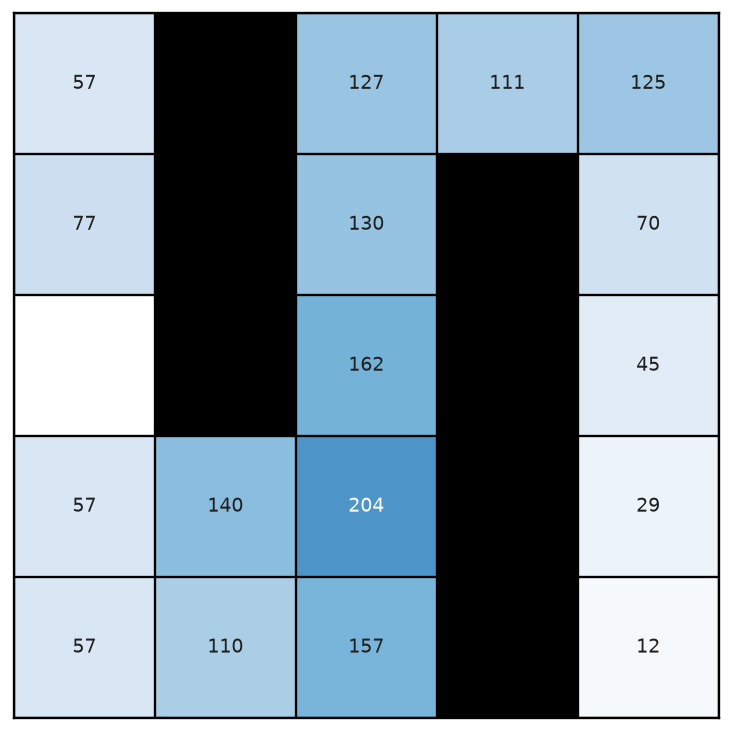

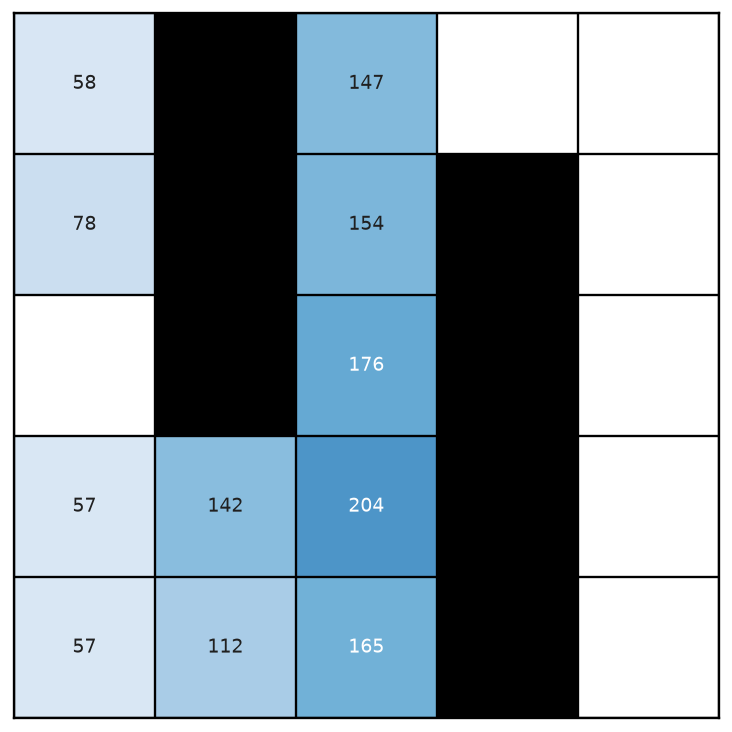

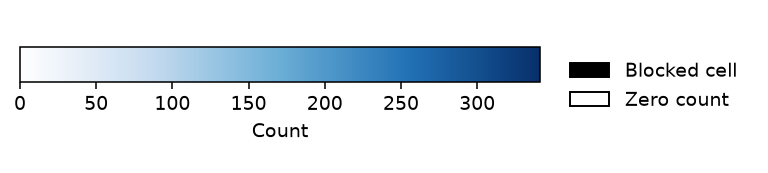

In [12]:
from matplotlib.patches import Patch

blue_cmap = LinearSegmentedColormap.from_list(
    'count_blue', ['#ffffff', '#c6dbef', '#6baed6', '#2171b5', '#08306b']
)
shared_vmax = max(
    item_spawn_counts.max(),
    pickup_counts['Greedy'].max(),
    pickup_counts['v8.5.31'].max(),
)

mask = np.zeros((5, 5), dtype=bool)
for row, col in blocked_cells:
    mask[row, col] = True


def plot_count_grid(grid):
    display_grid = np.ma.array(grid, mask=mask)
    cmap = blue_cmap.copy()
    cmap.set_bad('black')

    fig, ax = plt.subplots(figsize=(5.2, 5.2), dpi=140)
    ax.imshow(
        display_grid, cmap=cmap, vmin=0, vmax=shared_vmax,
        interpolation='nearest',
    )
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticks(np.arange(-0.5, 5, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 5, 1), minor=True)
    ax.grid(which='minor', color='black', linewidth=1.2)
    ax.tick_params(which='both', bottom=False, left=False)
    for spine in ax.spines.values():
        spine.set_color('black')
        spine.set_linewidth(1.2)

    for row in range(5):
        for col in range(5):
            if mask[row, col]:
                continue
            value = int(grid[row, col])
            if value == 0:
                continue
            text_color = 'white' if value > 0.48 * shared_vmax else '#202020'
            ax.text(
                col, row, f'{value:,}', ha='center', va='center',
                color=text_color, fontsize=10,
            )

    fig.tight_layout(pad=0.6)
    plt.show()


plot_count_grid(item_spawn_counts)
plot_count_grid(pickup_counts['Greedy'])
plot_count_grid(pickup_counts['v8.5.31'])

# Standalone shared legend for all three figures.
legend_fig, legend_ax = plt.subplots(figsize=(6.4, 1.35), dpi=140)
legend_ax.set_axis_off()
colorbar_ax = legend_fig.add_axes([0.08, 0.52, 0.58, 0.18])
mappable = plt.cm.ScalarMappable(
    norm=plt.Normalize(vmin=0, vmax=shared_vmax), cmap=blue_cmap
)
colorbar = legend_fig.colorbar(mappable, cax=colorbar_ax, orientation='horizontal')
colorbar.set_label('Count')
legend_ax.legend(
    handles=[
        Patch(facecolor='black', edgecolor='black', label='Blocked cell'),
        Patch(facecolor='white', edgecolor='black', label='Zero count'),
    ],
    loc='center right', frameon=False,
)
plt.show()